# Vanilla Optimisation


In [1]:
import warnings
import numpy as np
from fmpy import *
fmu_filename = 'andris_tut.cstr_model.fmu'
from time import sleep


def simulator(params):

    Ci, Ti, Tci, Qc = [0.97, 351.5, 351.6, 150]
    UA, k_0 = params
    y0 = np.array([0.1,430,416])

    start_values={'UA':UA,'k_0':k_0,'Ci':Ci,'Ti':Ti,'Tci':Tci,'Qc':Qc}

    result = simulate_fmu(fmu_filename,start_values=start_values,stop_time=20,solver='Euler',step_size=0.01,output_interval=0.01)
    sleep(0.1)

    output = np.array([result[-1][1], result[-1][2], result[-1][3]])
    output_5 = np.array([result[-5][1], result[-5][2], result[-5][3]])

    # Check tolerance 
    abs_error = abs(output - output_5)
    rel_error = abs_error*100/y0
    error_percentage = 1

    # If simulation is outside of local tolerance, then issue warning and return array of null values
    if any(rel_error>error_percentage):
        warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
        #raise RuntimeError('Not converged; don"t count')

    return output

    

    

ModuleNotFoundError: No module named 'fmpy'

In [2]:
true_params = [7E5, 7.2E10]
observation = simulator(true_params)
observation

array([1.07831733e-01, 4.28696634e+02, 4.15091345e+02])

In [ ]:
from time import sleep
def summary_stat(y_pred, y_true):
    return np.sum((y_pred-y_true)**2)

def objective_function(params):

    
    
    y0 = np.array([0.1,430,416])
    
    y_pred = simulator([params[0]*1E5, params[1]*1E10])
    
    res = summary_stat(y_pred/y0, observation/y0)
    
    return res
    

from scipy.optimize import minimize
store=[]

for it in range(100):
    param_0 = [np.random.rand(1)*10,np.random.rand(1)*10]
    res = minimize(objective_function,param_0,bounds=((6,10),(1,10)),)
    if res.success:
        print(param_0)
        print(res.x)
        
        store.append(res.x)

[array([1.14608166]), array([3.6398572])]
[6.97328453 7.18879412]
[array([6.07681778]), array([6.16512161])]
[6.99427365 7.19759838]


/tmp/ipykernel_439526/515919298.py:29: RuntimeWarning: Solution not converged. [2.82779605 0.11868807 0.10340567]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/tmp/ipykernel_439526/515919298.py:29: RuntimeWarning: Solution not converged. [2.82779565 0.11868806 0.10340566]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/tmp/ipykernel_439526/515919298.py:29: RuntimeWarning: Solution not converged. [2.82779788 0.11868812 0.10340572]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)


[array([8.40438726]), array([9.53185409])]
[7.01037629 7.20441867]
[array([5.2008334]), array([9.60027893])]
[7.07856762 7.23282384]
[array([6.77279325]), array([9.36327138])]
[7.53604957 7.41415568]
[array([4.27846968]), array([8.53342312])]
[6.9114093  7.16241858]
[array([9.80105342]), array([5.57497461])]
[7.23755992 7.29774699]
[array([6.90700064]), array([0.98286559])]
[7.65093056 7.4572494 ]
[array([2.63520781]), array([4.25930089])]
[10.          6.92152972]
[array([6.86051805]), array([9.71646879])]
[7.69865712 7.47487317]
[array([0.2661026]), array([4.85703996])]
[6.99694181 7.19869867]
[array([5.18793666]), array([8.08433221])]
[7.0002902  7.20007634]
[array([1.00954366]), array([3.16188886])]
[6.9515916  7.17957543]
[array([3.28152081]), array([2.53277877])]
[7.49404236 7.39819996]
[array([1.7397429]), array([8.76055819])]
[6.85910329 7.13982461]


(array([2., 0., 0., 0., 5., 0., 0., 1., 1., 1.]),
 array([6.29176619, 6.44386336, 6.59596054, 6.74805772, 6.9001549 ,
        7.05225208, 7.20434925, 7.35644643, 7.50854361, 7.66064079,
        7.81273797]),
 <BarContainer object of 10 artists>)

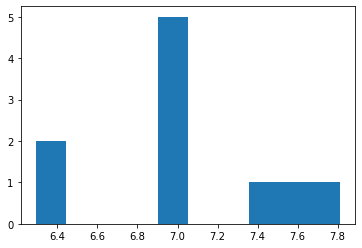

In [5]:
import matplotlib.pyplot as plt
plt.hist([item[0] for item in store])

(array([2., 0., 0., 0., 2., 3., 0., 1., 1., 1.]),
 array([6.87924263, 6.942956  , 7.00666937, 7.07038275, 7.13409612,
        7.19780949, 7.26152287, 7.32523624, 7.38894961, 7.45266299,
        7.51637636]),
 <BarContainer object of 10 artists>)

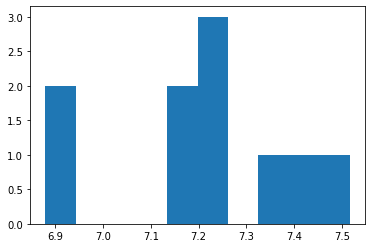

In [6]:
plt.hist([item[1] for item in store])

In [9]:
from functools import partial

from tools import run_sbi, pre_simulator
simulator = partial(pre_simulator, [0.97, 351.5, 351.6, 150])


In [17]:

store=[]

for it in range(100):
    param_0 = [np.random.rand(1)*10,np.random.rand(1)*10]
    res = minimize(objective_function,param_0,bounds=((6,10),(1,10)),)
    if res.success:
        print(param_0)
        print(res.x)
        
        store.append(res.x)

ERROR! Session/line number was not unique in database. History logging moved to new session 571
[array([0.46082371]), array([0.90438968])]
[6.41596196 6.93861401]
[array([1.42025557]), array([5.42419279])]
[6.27483994 6.87052724]
[array([7.49987227]), array([2.84141082])]
[8.40294029 7.71810612]
[array([3.71114768]), array([1.86243002])]
[6.25964439 6.86303538]
[array([8.98991721]), array([4.38967953])]
[8.97977669 7.89297437]
[array([8.17946223]), array([3.01744667])]
[8.71536029 7.8167209 ]
[array([1.22764944]), array([7.37971423])]
[6.29040926 6.87807332]
[array([9.05426165]), array([2.79023735])]
[9.69195815 8.09337163]
[array([5.88549647]), array([4.16451144])]
[6.38410257 6.92335376]
[array([1.75297716]), array([9.67157826])]
[6.97643275 7.19017943]
[array([8.18382228]), array([7.87041706])]
[8.18813392 7.64760229]
[array([6.75176875]), array([9.00658022])]
[7.18728695 7.2775725 ]
[array([9.2437881]), array([1.29116913])]
[9.92430909 8.1556458 ]
[array([5.45714808]), array([7.581

/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [7.35955886 0.22830255 0.25519102]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [7.35956096 0.22830262 0.25519114]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [7.35955667 0.22830243 0.25519093]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)


KeyboardInterrupt: 

(array([2., 2., 2., 0., 0., 0., 0., 2., 0., 1.]),
 array([6.        , 6.3271879 , 6.65437581, 6.98156371, 7.30875162,
        7.63593952, 7.96312742, 8.29031533, 8.61750323, 8.94469114,
        9.27187904]),
 <BarContainer object of 10 artists>)

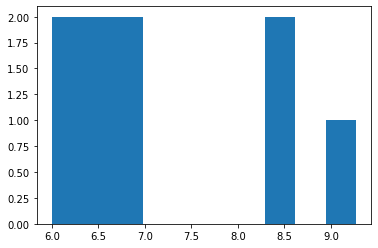

In [12]:
plt.hist([item[0] for item in store])